# EDA on Cars Data Set — Practice Notebook

We will explore the **Cars** data set and perform Exploratory Data Analysis (EDA).

**Topics covered:**
- Basic data exploration
- Removing duplicates
- Outlier treatment
- Missing value treatment
- Univariate analysis
- Bivariate analysis
- Normalization and Scaling (numerical variables)
- Encoding (categorical variables)

**Instructions:** Each section below tells you *what to do*. Write your own code in the empty cell that follows each instruction. Do not look at the solution notebook until you've tried it yourself!

## Step 1: Import Libraries

- Import `pandas` as `pd`
- Import `numpy` as `np`
- Import `matplotlib.pyplot` as `plt`
- Import `seaborn` as `sns`

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

## Step 2: Load the Data Set

- Read the file `Cars.xlsx` into a DataFrame called `cr` using `pd.read_excel()`

In [3]:
df = pd.read_excel("Cars.xlsx")

## Step 3: Clean Column Names

- Replace spaces in column names with underscores
- Convert column names to Title Case (e.g. `MARITAL STATUS` -> `Marital_Status`)

In [4]:
# TODO: write your code here
df.columns = df.columns.str.replace(" ", "_")

In [5]:
df.columns = df.columns.str.title()

In [6]:
df.columns

Index(['Index', 'Income', 'Marital_Status', 'Sex', 'Education', 'Job',
       'Travel_Time', 'Use', 'Miles_Clocked', 'Car_Type', 'Car_Age', 'City',
       'Postal_Code'],
      dtype='object')

## Step 4: Basic Data Exploration

Check the following:
- `head()` — first 5 rows
- `shape` — number of rows and columns
- `info()` — column data types and non-null counts
- `describe()` — summary statistics of numerical columns

In [7]:
# TODO: write your code here
df.head(10)

,Index,Income,Marital_Status,Sex,Education,Job,Travel_Time,Use,Miles_Clocked,Car_Type,Car_Age,City,Postal_Code
0,1,125301.24250,No,F,Bachelors,Blue Collar,45.703013,Commercial,17430.0,Sports Car,7.0,Texas,42420.0
1,2,50815.44531,No,M,High School,NaN,20.591628,Private,18930.0,Minivan,1.0,Texas,42420.0
2,3,62977.82416,NaN,F,Bachelors,Clerical,33.639949,Private,NaN,SUV,1.0,Texas,42420.0
3,4,77099.96624,No,F,NaN,Lawyer,15.415676,NaN,18300.0,Sports Car,11.0,Texas,42420.0
4,5,130794.57420,No,M,High School,NaN,NaN,Commercial,28340.0,Panel Truck,10.0,Texas,42420.0
5,6,NaN,NaN,F,High School,Home Maker,48.360191,NaN,6000.0,SUV,5.0,Texas,42420.0
6,7,87460.05269,No,M,High School,Manager,45.000488,NaN,15420.0,Minivan,1.0,Texas,42420.0
7,8,NaN,Yes,F,High School,Blue Collar,15.665947,NaN,11290.0,Sports Car,1.0,Texas,NaN
8,9,NaN,NaN,F,NaN,Clerical,26.392961,NaN,10030.0,SUV,1.0,Texas,42420.0
9,10,NaN,Yes,M,High School,Blue Collar,27.490749,NaN,NaN,Panel Truck,NaN,Texas,42420.0


In [8]:
df.shape

(303, 13)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Index           303 non-null    int64  
 1   Income          260 non-null    float64
 2   Marital_Status  275 non-null    object 
 3   Sex             297 non-null    object 
 4   Education       259 non-null    object 
 5   Job             257 non-null    object 
 6   Travel_Time     262 non-null    float64
 7   Use             250 non-null    object 
 8   Miles_Clocked   278 non-null    float64
 9   Car_Type        293 non-null    object 
 10  Car_Age         283 non-null    float64
 11  City            297 non-null    object 
 12  Postal_Code     300 non-null    float64
dtypes: float64(5), int64(1), object(7)
memory usage: 30.9+ KB


In [10]:
df.describe()

,Index,Income,Travel_Time,Miles_Clocked,Car_Age,Postal_Code
count,303.000000,260.000000,262.000000,278.000000,283.000000,300.000000
mean,139.640264,50025.162170,34.282098,13591.978417,6.265018,50712.196667
std,85.178422,41186.807914,14.910178,7167.328655,5.111218,24141.029290
min,1.000000,0.000000,5.000000,1500.000000,1.000000,11435.000000
25%,62.500000,20452.885023,24.449874,7900.000000,1.000000,42420.000000
50%,138.000000,44571.590870,33.564757,12065.000000,6.000000,47150.000000
75%,213.500000,66485.761387,43.907339,18240.000000,10.000000,61701.000000
max,289.000000,204667.589700,83.617643,38000.000000,20.000000,90049.000000


## Step 5: Check for Duplicate Records

- Count duplicate rows using `duplicated().sum()`
- Drop duplicate rows in place using `drop_duplicates()`
- Confirm no duplicates remain

In [11]:
# TODO: write your code here
df.duplicated().sum()

np.int64(14)

In [12]:
df.drop_duplicates()

,Index,Income,Marital_Status,Sex,Education,Job,Travel_Time,Use,Miles_Clocked,Car_Type,Car_Age,City,Postal_Code
0,1,125301.24250,No,F,Bachelors,Blue Collar,45.703013,Commercial,17430.0,Sports Car,7.0,Texas,42420.0
1,2,50815.44531,No,M,High School,NaN,20.591628,Private,18930.0,Minivan,1.0,Texas,42420.0
2,3,62977.82416,NaN,F,Bachelors,Clerical,33.639949,Private,NaN,SUV,1.0,Texas,42420.0
3,4,77099.96624,No,F,NaN,Lawyer,15.415676,NaN,18300.0,Sports Car,11.0,Texas,42420.0
4,5,130794.57420,No,M,High School,NaN,NaN,Commercial,28340.0,Panel Truck,10.0,Texas,42420.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,285,15251.52473,No,M,High School,Clerical,31.315058,Private,3030.0,Sports Car,1.0,Las Vegas,44412.0
299,286,18408.39545,No,M,High School,Clerical,42.619118,Private,7440.0,NaN,1.0,Las Vegas,NaN
300,287,NaN,No,M,High School,Clerical,36.533624,Private,7660.0,SUV,NaN,Las Vegas,44412.0
301,288,NaN,Yes,F,High School,NaN,60.884292,Private,19550.0,Van,1.0,Las Vegas,44412.0


## Step 6: Drop Irrelevant Columns

- The `Index` column is just a row identifier and carries no information. Drop it (`axis=1`, `inplace=True`).

In [13]:
if "Index" in df.columns:
    df.drop("Index", axis=1, inplace=True)
    print("Yes - Index column dropped")
else:
    print("No - Index column not found")

Yes - Index column dropped


## Step 7: Separate Categorical and Continuous Columns

- Convert `Postal_Code` to the `category` dtype (it's really a label, not a number)
- Build two lists: `cat` for categorical (text) columns, `con` for continuous (numerical) columns
- Loop through `cr` columns and sort them into `cat` / `con` accordingly (hint: use `pd.api.types.is_numeric_dtype()`)

In [14]:
# TODO: write your code here
if "Postal_Code" in df.columns:
    df["Postal_Code"] = df["Postal_Code"].astype("category")
    print("Postal_Code converted to category")
else:
    print("Postal_Code column not found")

Postal_Code converted to category


## Step 8: Check for Missing Values

- Use `isnull().sum()` to see how many missing values each column has

In [15]:
# TODO: write your code here
df.isnull().sum()

Income            43
Marital_Status    28
Sex                6
Education         44
Job               46
Travel_Time       41
Use               53
Miles_Clocked     25
Car_Type          10
Car_Age           20
City               6
Postal_Code        3
dtype: int64

## Step 9: Visualize Outliers (Before Treatment)

- Plot a boxplot of all continuous columns using `sns.boxplot(data=cr[con])` to visually spot outliers

In [16]:
df.columns

Index(['Income', 'Marital_Status', 'Sex', 'Education', 'Job', 'Travel_Time',
       'Use', 'Miles_Clocked', 'Car_Type', 'Car_Age', 'City', 'Postal_Code'],
      dtype='object')

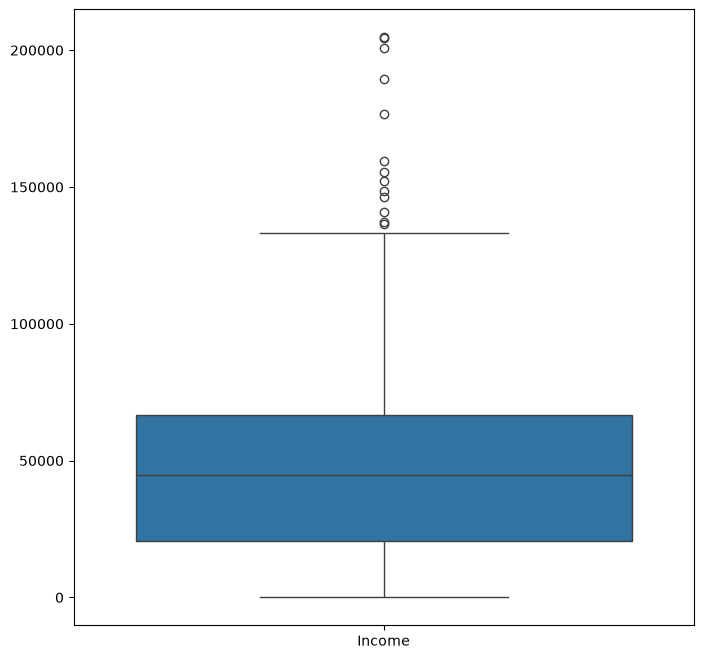

In [17]:
# TODO: write your code here
con = ["Income"]
plt.figure(figsize=(8,8))
sns.boxplot(data=df[con])
plt.show()

## Step 10: Treat Outliers (IQR Method)

For every continuous column:
- Compute Q1 (25th percentile) and Q3 (75th percentile)
- Compute `IQR = Q3 - Q1`
- Compute `upper = Q3 + 1.5*IQR` and `lower = Q1 - 1.5*IQR`
- **Cap** values above `upper` to `upper`, and **floor** values below `lower` to `lower` (use `np.where`)
- Re-plot the boxplot to confirm outliers are treated

In [18]:
# TODO: write your code here
for col in con:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print("Column:", col)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("Lower Limit:", lower)
    print("Upper Limit:", upper)

    df[col] = np.where(
        df[col] > upper,
        upper,
        np.where(
            df[col] < lower,
            lower,
            df[col]
        )
    )

    print("Outliers treated successfully\n")

Column: Income
Q1: 20452.885022500002
Q3: 66485.7613875
Lower Limit: -48596.429524999985
Upper Limit: 135535.07593499997
Outliers treated successfully



## Step 11: Impute Missing Values — Continuous Columns

- For each continuous column, replace missing (`NaN`) values with that column's **median**

*(Reminder: Continuous variables -> use Median. Categorical variables -> use Mode.)*

In [19]:
con = df.select_dtypes(include="number").columns
print(con)

Index(['Income', 'Travel_Time', 'Miles_Clocked', 'Car_Age'], dtype='object')


In [20]:
for col in con:
    df[col] = df[col].fillna(df[col].median())
    print(col, "missing values replaced with median")

Income missing values replaced with median
Travel_Time missing values replaced with median
Miles_Clocked missing values replaced with median
Car_Age missing values replaced with median


## Step 12: Impute Missing Values — Categorical Columns

- For each categorical column, replace missing values with that column's **mode** (most frequent value)

In [21]:
cat = df.select_dtypes(include="object").columns

print(cat)

Index(['Marital_Status', 'Sex', 'Education', 'Job', 'Use', 'Car_Type', 'City'], dtype='object')


In [22]:
for col in cat:
    df[col] = df[col].fillna(df[col].mode()[0])
    print(col, "filled with mode")

Marital_Status filled with mode
Sex filled with mode
Education filled with mode
Job filled with mode
Use filled with mode
Car_Type filled with mode
City filled with mode


## Step 13: Confirm No Missing Values Remain

- Run `isnull().sum()` on the full DataFrame to confirm 0 missing values everywhere

In [23]:
# TODO: write your code here
df.isnull().sum()

Income            0
Marital_Status    0
Sex               0
Education         0
Job               0
Travel_Time       0
Use               0
Miles_Clocked     0
Car_Type          0
Car_Age           0
City              0
Postal_Code       3
dtype: int64

In [24]:
df.to_excel("Cleaned_Cars.xlsx", index=False)

## Step 14: Univariate Analysis

- Plot a boxplot of `Income` to check its distribution and skewness
- Plot a countplot of `Education` split by `Sex` (use `hue='Sex'`) to compare education levels between males and females

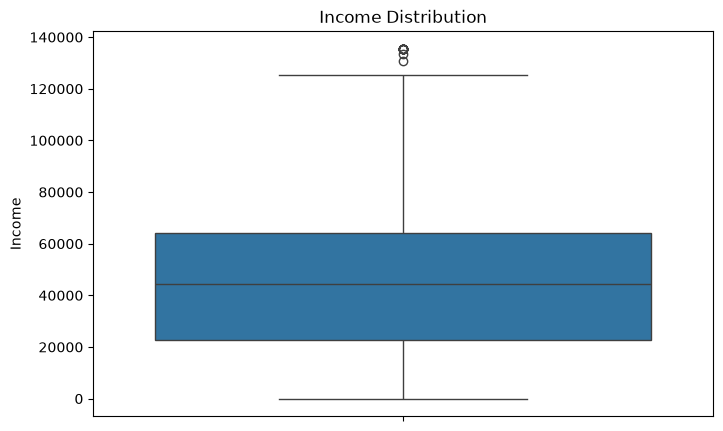

In [25]:
# TODO: write your code here
plt.figure(figsize=(8,5))

sns.boxplot(y=df["Income"])

plt.title("Income Distribution")
plt.ylabel("Income")

plt.show()

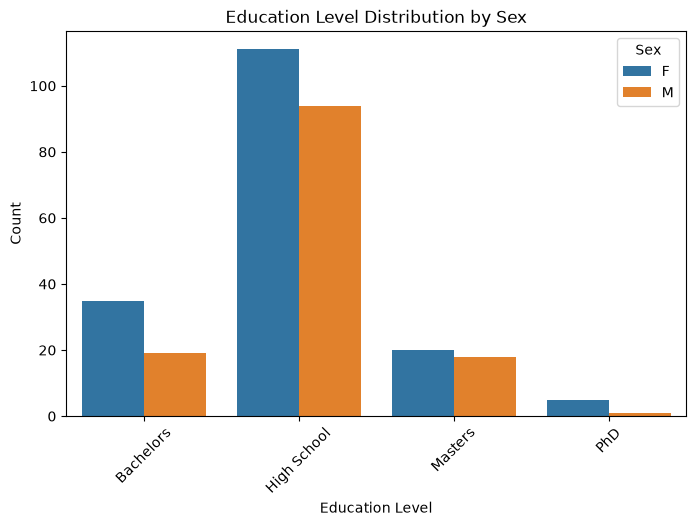

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Education",
    hue="Sex"
)

plt.title("Education Level Distribution by Sex")
plt.xlabel("Education Level")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

## Step 15: Bivariate Analysis — Pairplot

- Use `sns.pairplot()` on the continuous columns (`cr[con]`) to see pairwise relationships

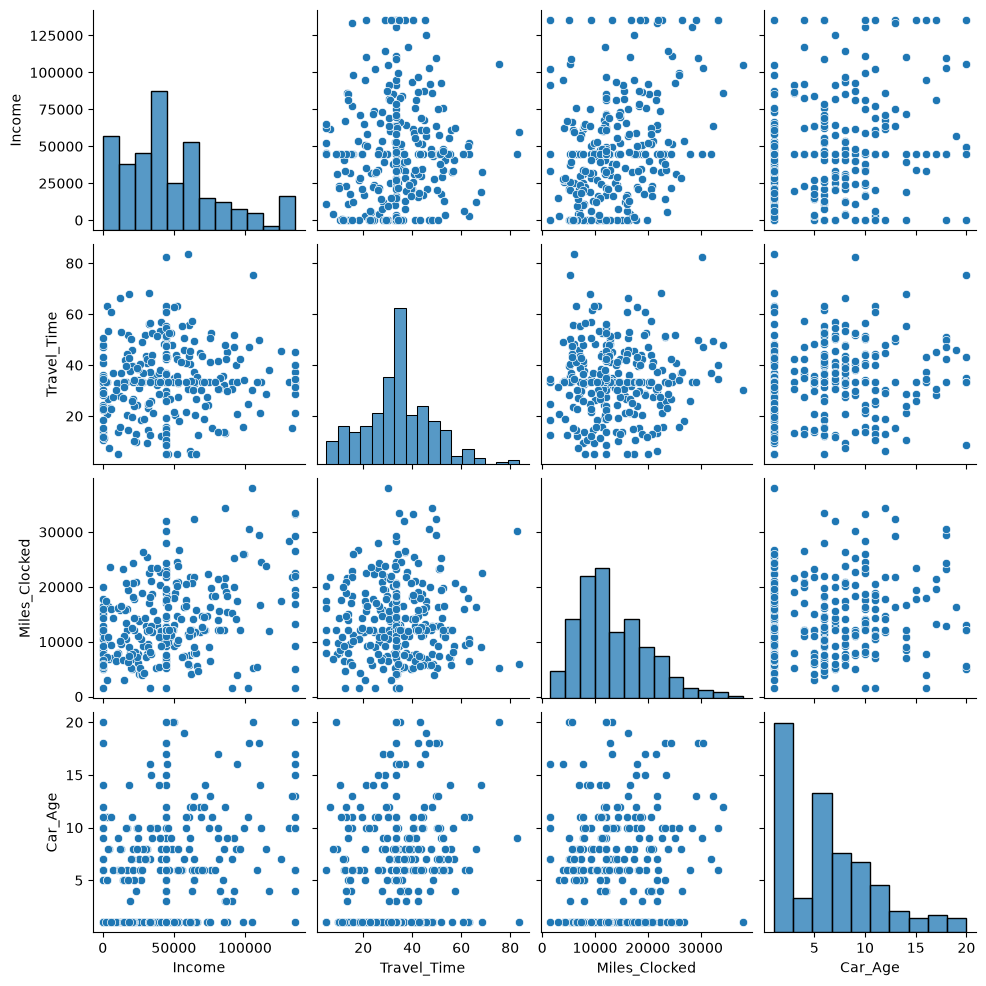

In [27]:
# TODO: write your code here
sns.pairplot(df[con])

plt.show()

## Step 16: Bivariate Analysis — Correlation Heatmap

- Compute the correlation matrix of the continuous columns with `.corr()`
- Visualize it with `sns.heatmap()` (use `annot=True` to show correlation values)

In [28]:
# TODO: write your code here
corr_matrix = df[con].corr()

corr_matrix

,Income,Travel_Time,Miles_Clocked,Car_Age
Income,1.000000,0.057102,0.316664,0.261624
Travel_Time,0.057102,1.000000,0.030640,0.141555
Miles_Clocked,0.316664,0.030640,1.000000,0.134838
Car_Age,0.261624,0.141555,0.134838,1.000000


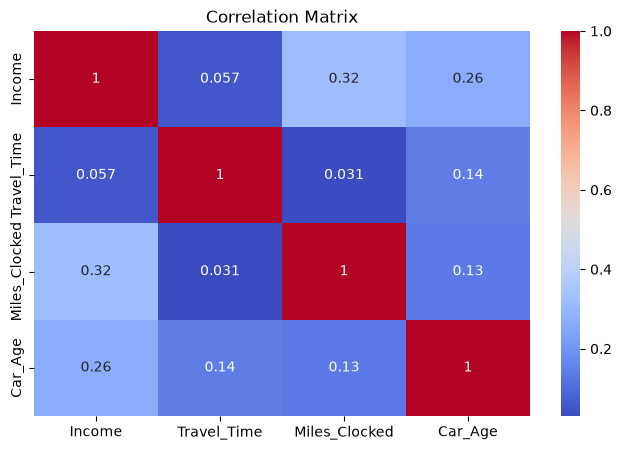

In [29]:
plt.figure(figsize=(8,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

## Step 17: Normalization and Scaling

- Import `StandardScaler` from `sklearn.preprocessing`
- Fit and transform the continuous columns (`cr[con]`) using `StandardScaler`
- Store the scaled result in a new DataFrame `cr_std` with the same column names as `con`

In [30]:
# TODO: write your code here
from sklearn.preprocessing import StandardScaler

In [31]:
scaler = StandardScaler() # Create scaler object
cr_std = scaler.fit_transform(df[con]) # Fit and transform continuous columns

In [32]:
# Convert scaled data into DataFrame
cr_std = pd.DataFrame(
    cr_std,
    columns=con
)

In [33]:
cr_std.head()

,Income,Travel_Time,Miles_Clocked,Car_Age
0,2.266849,0.832197,0.577357,0.152590
1,0.083588,-0.982151,0.795831,-1.064114
2,0.440081,-0.039383,-0.204054,-1.064114
3,0.854016,-1.356124,0.704072,0.963726
4,2.427865,-0.044816,2.166395,0.760942


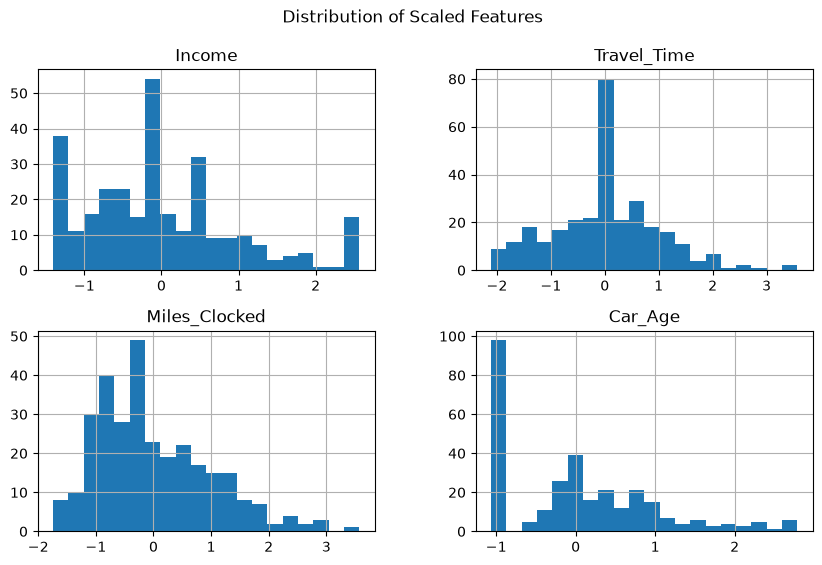

In [35]:
cr_std.hist(figsize=(10,6), bins=20)

plt.suptitle("Distribution of Scaled Features")
plt.show()

## Step 18: Encoding Categorical Variables

- Convert each categorical column to the `category` dtype
- Use `pd.get_dummies()` on the categorical columns with `drop_first=True` to one-hot encode them
- Store the result in `dummies`

In [36]:
# TODO: write your code here
for col in cat:
    df[col] = df[col].astype("category")

In [37]:
dummies = pd.get_dummies(
    df[cat],
    drop_first=True
)

In [38]:
dummies.head()

,Marital_Status_Yes,Sex_M,Education_High School,Education_Masters,Education_PhD,Job_Clerical,Job_Doctor,Job_Home Maker,Job_Lawyer,Job_Manager,...,City_Houston,City_Las Vegas,City_Los Angeles,City_New Albany,City_New York City,City_Philadelphia,City_San Francisco,City_Seattle,City_Texas,City_Washington
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,False,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,False,False,True,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
4,False,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


## Step 19: Combine Scaled + Encoded Data

- Concatenate `cr_std` (scaled continuous columns) and `dummies` (encoded categorical columns) along `axis=1`
- This final DataFrame is now ready to be used for modeling

In [39]:
# TODO: write your code here
final_df = pd.concat(
    [cr_std, dummies],
    axis=1
)

# View final dataset
final_df.head()

,Income,Travel_Time,Miles_Clocked,Car_Age,Marital_Status_Yes,Sex_M,Education_High School,Education_Masters,Education_PhD,Job_Clerical,...,City_Houston,City_Las Vegas,City_Los Angeles,City_New Albany,City_New York City,City_Philadelphia,City_San Francisco,City_Seattle,City_Texas,City_Washington
0,2.266849,0.832197,0.577357,0.152590,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,0.083588,-0.982151,0.795831,-1.064114,False,True,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,0.440081,-0.039383,-0.204054,-1.064114,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
3,0.854016,-1.356124,0.704072,0.963726,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,2.427865,-0.044816,2.166395,0.760942,False,True,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [40]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Income                 303 non-null    float64
 1   Travel_Time            303 non-null    float64
 2   Miles_Clocked          303 non-null    float64
 3   Car_Age                303 non-null    float64
 4   Marital_Status_Yes     303 non-null    bool   
 5   Sex_M                  303 non-null    bool   
 6   Education_High School  303 non-null    bool   
 7   Education_Masters      303 non-null    bool   
 8   Education_PhD          303 non-null    bool   
 9   Job_Clerical           303 non-null    bool   
 10  Job_Doctor             303 non-null    bool   
 11  Job_Home Maker         303 non-null    bool   
 12  Job_Lawyer             303 non-null    bool   
 13  Job_Manager            303 non-null    bool   
 14  Job_Professional       303 non-null    bool   
 15  Job_St

In [41]:
final_df.to_excel("Cars_Final_Preprocessed.xlsx", index=False)